In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
no_synapses = pd.read_csv("threshold_vs_currency.csv", index_col = 0)
with_synapses = pd.read_csv("threshold_vs_currency_with_synapses.csv", index_col = 0)

In [17]:
def has_ap(carrier, target, amplitude):
    ap_amplitude = no_synapses[ (no_synapses.Carrier == carrier) & (no_synapses.Target == target) ].Amplitude[0]
    return ap_amplitude <= amplitude

In [20]:
carrier = no_synapses.Carrier[0]
target = no_synapses.Target[0]

In [99]:
def find_ef_amplitude(carrier, target, initial_amplitude = 1000):
    amplitude = initial_amplitude
    amplitude_step = amplitude / 2
    last_amplitude = initial_amplitude * 2

    while abs(last_amplitude - amplitude) > 1:
        print(f"Testing {amplitude}")
        last_amplitude = amplitude

        if has_ap(carrier, target, amplitude):
            amplitude -= amplitude_step
        else:
            amplitude += amplitude_step
    
        amplitude_step = amplitude_step / 2
    
    print(f"Minimum amplitude for APs: {amplitude}")
    return amplitude

In [125]:
original = pd.read_csv("threshold_vs_currency_2.csv", index_col = 0)
better = pd.read_csv("threshold_vs_currency_with_synapses_2.csv", index_col = 0)

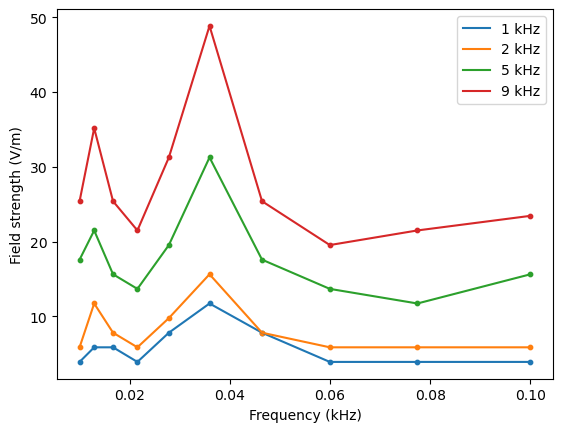

In [126]:
for carrier in original.Carrier.unique():
    ori = original[ original.Carrier == carrier ]
    bet = better[ better.Carrier == carrier ]
    plt.plot(ori.Target / 1000, ori.Amplitude - bet.Amplitude, label = f"{round(carrier / 1000)} kHz")
    plt.scatter(ori.Target / 1000, ori.Amplitude - bet.Amplitude, s = 10)

# plt.ylim(0, 1200)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Field strength (V/m)")
plt.legend()
plt.show()

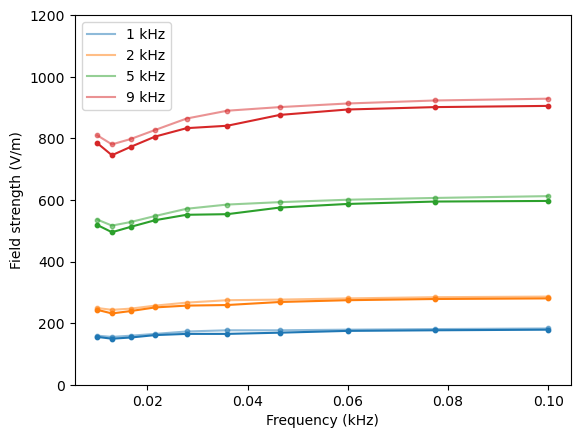

In [129]:
no_synapses = pd.read_csv("threshold_vs_currency_2.csv", index_col = 0)
with_synapses = pd.read_csv("threshold_vs_currency_with_synapses_2.csv", index_col = 0)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, carrier in enumerate(no_synapses.Carrier.unique()):
    no_ = no_synapses[ no_synapses.Carrier == carrier ]
    with_ = with_synapses[ with_synapses.Carrier == carrier ]
    plt.plot(no_.Target / 1000, no_.Amplitude, label = f"{round(carrier / 1000)} kHz", alpha = 0.5)
    plt.scatter(no_.Target / 1000, no_.Amplitude, s = 10, color = colors[i], alpha = 0.5)

    plt.plot(with_.Target / 1000, with_.Amplitude, color = colors[i])
    plt.scatter(with_.Target / 1000, with_.Amplitude, s = 10, color = colors[i])

plt.ylim(0, 1200)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Field strength (V/m)")
plt.legend()
plt.show()